In [5]:
%%capture
# Install Unsloth + dependencies
# We patch TRL on disk to disable optional integrations (weave, mergekit, llm_blender, liger_kernel)
# This is the same trick from 10a — TRL eagerly imports things we don't need
!pip install -q unsloth datasets
!pip install -q --no-deps trl peft accelerate bitsandbytes

import os, glob, re

trl_dir = "/usr/local/lib/python3.12/dist-packages/trl"
problem_libs = ["weave", "mergekit", "llm_blender", "liger_kernel"]

def _patch_line(line):
    leading = line[:len(line) - len(line.lstrip())]
    s = line.strip()
    m = re.match(r"^from\s+(\w+)[\.\w]*\s+import\s+(.+)$", s)
    if m and m.group(1) in problem_libs:
        names = []
        for p in m.group(2).rstrip(")").split(","):
            p = p.strip()
            names.append(p.split(" as ")[1].strip() if " as " in p else p)
        stubs = "; ".join(f"{n} = None" for n in names if n)
        return f"{leading}{stubs}  # was: {s}\n"
    m = re.match(r"^import\s+(\w+)", s)
    if m and m.group(1) in problem_libs:
        return f"{leading}{m.group(1)} = None  # was: {s}\n"
    return line

if os.path.exists(trl_dir):
    for fp in glob.glob(os.path.join(trl_dir, "**/*.py"), recursive=True):
        with open(fp) as f:
            lines = f.readlines()
        new = [_patch_line(l) for l in lines]
        if new != lines:
            with open(fp, "w") as f:
                f.writelines(new)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
print("[OK] Environment ready")

In [6]:
import torch 
import re
import random 
import numpy as np

SEED = 3407
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}GB")

CUDA available: True
Device: Tesla T4
VRAM: 15.64GB


In [7]:
from unsloth import FastLanguageModel

max_seq_length = 1024
lora_rank = 64

model, tokeniser = FastLanguageModel.from_pretrained(
    model_name="unsloth/SmolLM-135M-Instruct",
    max_seq_length=max_seq_length,
    load_in_4bit=True,
    fast_inference=False,
    max_lora_rank=lora_rank
)

model = FastLanguageModel.get_peft_model(
    model,
    r=lora_rank,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    lora_alpha=lora_rank,
    use_gradient_checkpointing="unsloth",
    random_state=SEED
)

print(f"[OK] SmolLM-135M with lora rank: {lora_rank}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.1: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Unsloth 2026.6.1 patched 30 layers with 30 QKV layers, 30 O layers and 30 MLP layers.


[OK] SmolLM-135M with lora rank: 64
Trainable params: 19,537,920


In [8]:
from datasets import load_dataset, Dataset
from typing import List

SYSTEM_PROMPT='''
Respond in the following format:
<reasoning>
...
</reasoning>
<answer>
...
</answer>
'''

XML_COT_FORMAT='''
<reasoning>
{resoning}
</reasoning>
<answer>
{answer}
</answer>
'''

def extract_xml_answer(text: str) -> str:
    ans = text.split("<answer>")[-1]
    ans = ans.split("</answer>")[0]
    return ans

def extract_hash_answer(text: str) -> None | str:
    if "####" not in text: 
        return None
    return text.split("####")[1].strip()

def get_gsm8k_questions(split:str="train") -> Dataset:
    data = load_dataset("openai/gsm8k", "main")[split]
    data = data.map(lambda x: {
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": x["question"]} 
        ],
        "answer": extract_hash_answer(x["answer"])
    })
    return data

dataset = get_gsm8k_questions()

print(f"[OK] Loaded dataset of length: {len(dataset):,}")
print(f"\nExample question: {dataset[0]["prompt"][1]["content"][:200]}...")
print(f"\nAnswer: {dataset[0]['answer']}")

[OK] Loaded dataset of length: 7,473

Example question: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?...

Answer: 72


In [9]:
from typing import Any

def correctness_reward_func(
        prompts: Any, 
        completions: List[List[dict[str, str]]],
        answer: List[str],
        **kwargs
    ) -> List[float]:
    responses = [c[0]["content"] for c in completions]
    extracted = [extract_xml_answer(r) for r in responses]
    return [2.0 if r == a else 0.0 for r, a in zip(extracted, answer)]

def int_reward_func(
    completions: List[List[dict[str, str]]],
    **kwargs
) -> List[float]:
    responses = [c[0]["content"] for c in completions]
    extracted = [extract_xml_answer(r) for r in responses]
    return [0.5 if r.isdigit() else 0.0 for r in extracted]

def strict_format_reward_func(completions: List[List[dict[str, str]]], **kwargs) -> List[float]:
    pattern = r"<reasoning>\n.*?\n</reasoning>\n<answer>\n.*?\n</answer>\n?$"
    responses = [c[0]["content"] for c in completions]
    matches = [re.match(pattern, r, re.DOTALL) for r in responses]
    return [0.5 if m else 0.0 for m in matches]

def soft_format_reward_func(completions: List[List[dict[str, str]]], **kwargs) -> List[float]: 
    pattern = r"<reasoning>.*?</reasoning>\s*<answer>.*?</answer>"
    responses = [c[0]["content"] for c in completions]
    matches = [re.match(pattern, r, re.DOTALL) for r in responses]
    return [0.5 if m else 0.0 for m in matches]

def count_xml(text: str) -> float:
    count = 0.0
    if text.count("<reasoning>\n") == 1: count += 0.125
    if text.count("\n</reasoning>\n") == 1: count += 0.125
    if text.count("\n<answer>\n") == 1: count += 0.125
    if text.count("\n</answer>") == 1: 
        count += 0.125
        count -= len(text.split("\n</answer>")[-1]) * 0.001
    return count

def xmlcount_reward_func(completions: List[List[dict[str, str]]], **kwargs):
    contents = [c[0]["content"] for c in completions]
    return [count_xml(c) for c in contents]

print("[OK] 5 reward functions defined")
print("     Max possible reward per response: +4.0")


[OK] 5 reward functions defined
     Max possible reward per response: +4.0


In [10]:
def fake_completion(text: str):
    return [[{"role": "assistant", "content": text}]]

# 1. Garbage response — no format, no structure
test1 = fake_completion("the answer is probably 42 because reasons")

# 2. Has format but wrong answer
test2 = fake_completion('''<reasoning>
let me think
</reasoning>
<answer>
42
</answer>''')

# 3. Perfect — format AND right answer
test3 = fake_completion('''<reasoning>
18 multiplied by 7 is 126
</reasoning>
<answer>
126
</answer>''')

ground_truth = ["126"]

for i, c in enumerate([test1, test2, test3], 1):
    print(f"\n=== Test {i} ===")
    print(f"Response: {c[0][0]['content'][:80]}...")
    print(f"  correctness:    {correctness_reward_func(None, c, ground_truth)[0]:+.2f}")
    print(f"  int_reward:     {int_reward_func(c)[0]:+.2f}")
    print(f"  strict_format:  {strict_format_reward_func(c)[0]:+.2f}")
    print(f"  soft_format:    {soft_format_reward_func(c)[0]:+.2f}")
    print(f"  xmlcount:       {xmlcount_reward_func(c)[0]:+.4f}")
    total = (correctness_reward_func(None, c, ground_truth)[0]
             + int_reward_func(c)[0]
             + strict_format_reward_func(c)[0]
             + soft_format_reward_func(c)[0]
             + xmlcount_reward_func(c)[0])
    print(f"  TOTAL:          {total:+.4f}")


=== Test 1 ===
Response: the answer is probably 42 because reasons...
  correctness:    +0.00
  int_reward:     +0.00
  strict_format:  +0.00
  soft_format:    +0.00
  xmlcount:       +0.0000
  TOTAL:          +0.0000

=== Test 2 ===
Response: <reasoning>
let me think
</reasoning>
<answer>
42
</answer>...
  correctness:    +0.00
  int_reward:     +0.00
  strict_format:  +0.50
  soft_format:    +0.50
  xmlcount:       +0.5000
  TOTAL:          +1.5000

=== Test 3 ===
Response: <reasoning>
18 multiplied by 7 is 126
</reasoning>
<answer>
126
</answer>...
  correctness:    +0.00
  int_reward:     +0.00
  strict_format:  +0.50
  soft_format:    +0.50
  xmlcount:       +0.5000
  TOTAL:          +1.5000


In [13]:
FastLanguageModel.for_inference(model)

sample_q = dataset[0]
prompt = tokeniser.apply_chat_template(
    sample_q["prompt"],
    tokenize=False,
    add_generation_prompt=True
)

print("=== QUESTION ===")
print(sample_q["prompt"][1]["content"])
print(f"\n=== EXPECTED ANSWER ===")
print(sample_q["answer"])

inputs = tokeniser(prompt, return_tensors="pt").to("cuda")
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=400,
        do_sample=True,
        temperature=0.8,
        top_p=0.95,
        pad_token_id=tokeniser.eos_token_id
    )

response = tokeniser.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
print(f"\n=== BASELINE MODEL OUTPUT (before GRPO) ===")
print(response)
print(f"\n=== AUTOMATED REWARD SCORE ===")
fake = fake_completion(response)
total = (correctness_reward_func(None, fake, [sample_q["answer"]])[0]
         + int_reward_func(fake)[0]
         + strict_format_reward_func(fake)[0]
         + soft_format_reward_func(fake)[0]
         + xmlcount_reward_func(fake)[0])
print(f"Total reward: {total:+.4f} (out of max +4.0)")

Both `max_new_tokens` (=400) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== QUESTION ===
Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?

=== EXPECTED ANSWER ===
72

=== BASELINE MODEL OUTPUT (before GRPO) ===
Here is the data:

**Clip Sales in April (48) and May (48.55) in a month:**

| Clip | Total Clip Sold in April (48) and May (48.55) in a month |
| --- | --- |
| 48 | 34 |
| 48.55 | 38.55 |
| 50 | 35.55 |
| 50.55 | 37.55 |

**Total Clip Sales in April (48) and May (48.55) in a month:**

| Total Clip Sales in April (48) and May (48.55) in a month |
| 50 | 48 |
| 48.55 | 47.55 |
| 48.55 | 45.55 |
| 50.55 | 45.55 |

**Average Clip Value (12.58) in April:**

| Average Clip Value (12.58) in April |
| 30.00 |
| 31.00 |
| 31.00 |
| 31.00 |

**Total Clip Value in April (48.55) and May (48.55) in a month:**

| Total Clip Value in April (48) and May (48.55) in a month |
| 50 | 48 |
| 48.55 | 49 |
| 48.55 | 49.55 |

**Average Clip

=== AUTOMATED REWARD SCO

In [15]:
from unsloth import PatchFastRL
from trl import GRPOConfig, GRPOTrainer

PatchFastRL("GRPO", FastLanguageModel)

# Critical hyperparameters for GRPO
training_args = GRPOConfig(
    output_dir = "outputs",

    # --- Learning rate (same as DPO range) ---
    learning_rate = 5e-6,
    adam_beta1 = 0.9,
    adam_beta2 = 0.99,
    weight_decay = 0.1,
    warmup_steps = 0.1,
    lr_scheduler_type = "cosine",
    optim = "paged_adamw_8bit",

    # --- The "G" in GRPO ---
    num_generations = 4,         # Reduced from default 6 for T4 memory
    # Each step generates 4 different responses to the SAME prompt
    # The advantage is computed RELATIVE to these 4 responses

    # --- Batch sizes ---
    per_device_train_batch_size = 1,
    gradient_accumulation_steps = 1,

    # --- Sequence lengths ---
    max_prompt_length = 256,
    max_completion_length = 512,

    # --- Training duration ---
    max_steps = 100,             # Demo only — production needs 300+
    save_steps = 50,
    logging_steps = 1,

    # --- Other ---
    max_grad_norm = 0.1,
    report_to = "none",
    seed = SEED,

    # --- Use TRL's reference (no vLLM for tiny models) ---
    use_vllm = False,
)

print("[OK] GRPOConfig ready")
print(f"     Group size (num_generations): {training_args.num_generations}")
print(f"     Max steps: {training_args.max_steps}")
print(f"     Learning rate: {training_args.learning_rate}")

Unsloth: UnslothBCOTrainer is already patched.
Unsloth: UnslothCPOTrainer is already patched.
Unsloth: UnslothDPOTrainer is already patched.
Unsloth: UnslothGKDTrainer is already patched.
Unsloth: UnslothGRPOTrainer is already patched.
Unsloth: UnslothKTOTrainer is already patched.
Unsloth: UnslothNashMDTrainer is already patched.
Unsloth: UnslothOnlineDPOTrainer is already patched.
Unsloth: UnslothORPOTrainer is already patched.
Unsloth: UnslothPPOTrainer is already patched.
Unsloth: UnslothPRMTrainer is already patched.
Unsloth: UnslothRewardTrainer is already patched.
Unsloth: UnslothRLOOTrainer is already patched.
Unsloth: UnslothSFTTrainer is already patched.
Unsloth: UnslothXPOTrainer is already patched.
Unsloth: We now expect `per_device_train_batch_size` * `gradient_accumulation_steps` * `world_size` to be a multiple of `num_generations`.
We will change the batch size of 1 to the `num_generations` of 4
[OK] GRPOConfig ready
     Group size (num_generations): 4
     Max steps: 1

In [16]:
# Create the GRPO trainer
trainer = GRPOTrainer(
    model = model,
    processing_class = tokeniser,
    reward_funcs = [
        xmlcount_reward_func,
        soft_format_reward_func,
        strict_format_reward_func,
        int_reward_func,
        correctness_reward_func,
    ],
    args = training_args,
    train_dataset = dataset,
)

print("[OK] GRPOTrainer ready")
print(f"     Training on {len(dataset):,} examples")
print(f"     5 reward functions active")
print(f"\n     Each step:")
print(f"       1. Sample 1 prompt")
print(f"       2. Generate {training_args.num_generations} responses")
print(f"       3. Score each with all 5 reward functions")
print(f"       4. Compute advantages = (reward - mean) / std")
print(f"       5. Update LoRA weights")

[OK] GRPOTrainer ready
     Training on 7,473 examples
     5 reward functions active

     Each step:
       1. Sample 1 prompt
       2. Generate 4 responses
       3. Score each with all 5 reward functions
       4. Compute advantages = (reward - mean) / std
       5. Update LoRA weights


In [17]:
# Switch back to training mode and train
FastLanguageModel.for_training(model)

trainer_stats = trainer.train()

print("\n[OK] GRPO training complete")
print(f"Final loss: {trainer_stats.training_loss:.4f}")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 16}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 7,473 | Num Epochs = 1 | Total steps = 100
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 1 x 1) = 4
 "-____-"     Trainable parameters = 19,537,920 of 154,052,928 (12.68% trained)
Passing `generation_config` together with generation-related arguments=({'disable_compile', 'pad_token_id', 'cache_implementation'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=512) and `max_length`(=2048) seem to have been set. `max_new_tokens` will 

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / xmlcount_reward_func / mean,rewards / xmlcount_reward_func / std,rewards / soft_format_reward_func / mean,rewards / soft_format_reward_func / std,rewards / strict_format_reward_func / mean,rewards / strict_format_reward_func / std,rewards / int_reward_func / mean,rewards / int_reward_func / std,rewards / correctness_reward_func / mean,rewards / correctness_reward_func / std
1,0.000000,0.000000,0.000000,211.250000,79.000000,389.000000,0.000000,211.250000,79.000000,389.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,358.250000,168.000000,512.000000,0.500000,204.500000,168.000000,241.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,400.750000,67.000000,512.000000,0.750000,67.000000,67.000000,67.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,137.750000,63.000000,253.000000,0.000000,137.750000,63.000000,253.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,508.250000,497.000000,512.000000,0.750000,497.000000,497.000000,497.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,220.500000,61.000000,512.000000,0.250000,123.333336,61.000000,174.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,187.250000,45.000000,512.000000,0.250000,79.000000,45.000000,145.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,278.750000,88.000000,512.000000,0.250000,201.000000,88.000000,361.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,150.500000,131.000000,192.000000,0.000000,150.500000,131.000000,192.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


Both `max_new_tokens` (=512) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Both `max_new_tokens` (=512) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

KeyboardInterrupt: 

In [18]:
# Generate after-training output on the same question
FastLanguageModel.for_inference(model)

inputs = tokeniser(prompt, return_tensors="pt").to("cuda")
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=400,
        do_sample=True,
        temperature=0.8,
        top_p=0.95,
        pad_token_id=tokeniser.eos_token_id,
    )

response_after = tokeniser.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
print("=== QUESTION ===")
print(sample_q["prompt"][1]["content"])
print(f"\n=== EXPECTED ANSWER ===")
print(sample_q["answer"])

print(f"\n=== AFTER GRPO TRAINING ===")
print(response_after)
print(f"\n=== REWARD ===")
fake = fake_completion(response_after)
total = (correctness_reward_func(None, fake, [sample_q["answer"]])[0]
         + int_reward_func(fake)[0]
         + strict_format_reward_func(fake)[0]
         + soft_format_reward_func(fake)[0]
         + xmlcount_reward_func(fake)[0])
print(f"Total: {total:+.4f}")

Both `max_new_tokens` (=400) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== QUESTION ===
Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?

=== EXPECTED ANSWER ===
72

=== AFTER GRPO TRAINING ===
What a great question!

Here's the solution:

"Total clips sold: 48,572 clips in April, 124,734 clips in May"

The total amount of clips sold in April and May is 48,572 and 124,734, respectively. To calculate the total amount sold in both months, we need to add up the two-sided figures.

Total amount sold: 48,572 + 124,734 = 51,284

#### 51,284

#### 51,284

#### 51,284

#### 51,284

#### 51,284

#### 51,284

#### 51,284

#### 51,284

#### 51,284

#### 51,284

#### 51,284

#### 51,284

#### 51,284

#### 51,284

#### 51,284

#### 51,284

#### 51,284

#### 51,284

#### 51,284

#### 51,284

#### 51,284

#### 51,284

#### 51,284

#### 51,284

#### 51,284

#### 51,284

#### 51,284

#### 5

=== REWARD ===
Total: +0.0000


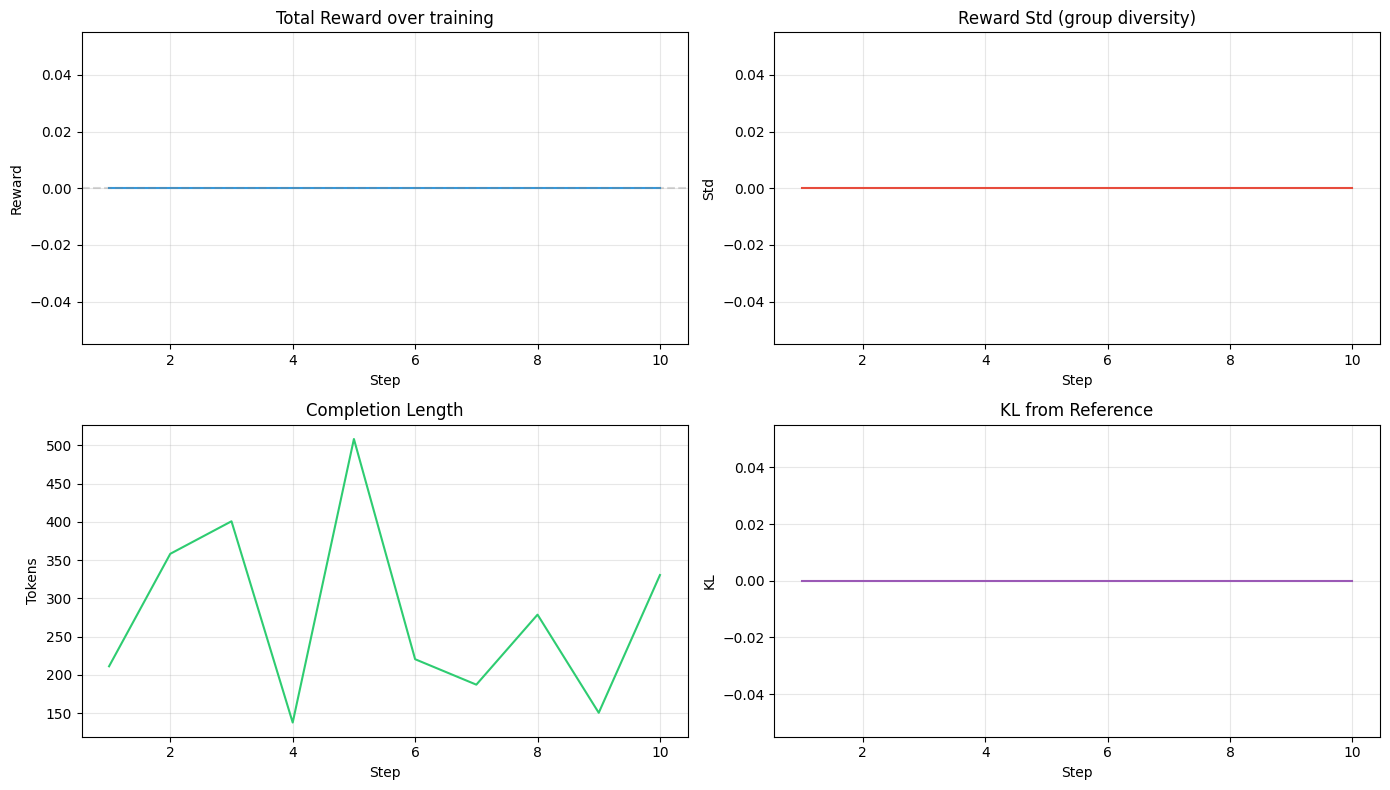


[OK] Plotted 10 steps


In [19]:
import matplotlib.pyplot as plt

# Pull metrics from the trainer's log history
log_history = trainer.state.log_history

steps, rewards, reward_stds, completion_lengths, kls = [], [], [], [], []
for entry in log_history:
    if "reward" in entry:
        steps.append(entry.get("step", 0))
        rewards.append(entry.get("reward", 0))
        reward_stds.append(entry.get("reward_std", 0))
        completion_lengths.append(entry.get("completion_length", 0))
        kls.append(entry.get("kl", 0))

if not steps:
    print("[WARN] No reward logs found")
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    axes[0,0].plot(steps, rewards, color='#3498db')
    axes[0,0].set_title("Total Reward over training")
    axes[0,0].set_xlabel("Step"); axes[0,0].set_ylabel("Reward")
    axes[0,0].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    axes[0,0].grid(alpha=0.3)

    axes[0,1].plot(steps, reward_stds, color='#e74c3c')
    axes[0,1].set_title("Reward Std (group diversity)")
    axes[0,1].set_xlabel("Step"); axes[0,1].set_ylabel("Std")
    axes[0,1].grid(alpha=0.3)

    axes[1,0].plot(steps, completion_lengths, color='#2ecc71')
    axes[1,0].set_title("Completion Length")
    axes[1,0].set_xlabel("Step"); axes[1,0].set_ylabel("Tokens")
    axes[1,0].grid(alpha=0.3)

    axes[1,1].plot(steps, kls, color='#9b59b6')
    axes[1,1].set_title("KL from Reference")
    axes[1,1].set_xlabel("Step"); axes[1,1].set_ylabel("KL")
    axes[1,1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("/content/grpo_metrics.png", dpi=80)
    plt.show()
    print(f"\n[OK] Plotted {len(steps)} steps")

In [21]:
# Sample 20 prompts and break down the reward
N_SAMPLES = 20

FastLanguageModel.for_inference(model)
breakdown = {
    "correctness": [], "int": [], "strict_format": [],
    "soft_format": [], "xmlcount": [],
}

import random
test_indices = random.sample(range(len(dataset)), N_SAMPLES)

print("Sampling 20 random training prompts post-GRPO...\n")
for i, idx in enumerate(test_indices):
    sample = dataset[idx]
    p = tokeniser.apply_chat_template(sample["prompt"], tokenize=False, add_generation_prompt=True)
    inp = tokeniser(p, return_tensors="pt").to("cuda")
    with torch.no_grad():
        out = model.generate(
            **inp, max_new_tokens=300, do_sample=True,
            temperature=0.8, top_p=0.95,
            pad_token_id=tokeniser.eos_token_id,
        )
    resp = tokeniser.decode(out[0][inp.input_ids.shape[1]:], skip_special_tokens=True)
    fake = fake_completion(resp)

    breakdown["correctness"].append(correctness_reward_func(None, fake, [sample["answer"]])[0])
    breakdown["int"].append(int_reward_func(fake)[0])
    breakdown["strict_format"].append(strict_format_reward_func(fake)[0])
    breakdown["soft_format"].append(soft_format_reward_func(fake)[0])
    breakdown["xmlcount"].append(xmlcount_reward_func(fake)[0])

    print(f"  [{i+1:2d}/{N_SAMPLES}] correct={breakdown['correctness'][-1]:.1f}  "
          f"format={breakdown['strict_format'][-1]:.1f}  xml={breakdown['xmlcount'][-1]:.3f}")

print(f"\n=== AVERAGE REWARD BY FUNCTION (across {N_SAMPLES} samples) ===")
for k, v in breakdown.items():
    avg = sum(v) / len(v)
    pct_nonzero = 100 * sum(1 for x in v if x > 0) / len(v)
    print(f"  {k:<14}: avg={avg:+.4f}  fired_in={pct_nonzero:5.1f}% of samples")

Both `max_new_tokens` (=300) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Sampling 20 random training prompts post-GRPO...



KeyboardInterrupt: 

In [22]:
# Diagnostic summary

avg_correct = sum(breakdown["correctness"]) / len(breakdown["correctness"])
avg_format = sum(breakdown["strict_format"]) / len(breakdown["strict_format"])
avg_xml = sum(breakdown["xmlcount"]) / len(breakdown["xmlcount"])

# Reward std diagnostic
import numpy as np
final_std = np.mean(reward_stds[-10:]) if reward_stds else 0
initial_std = np.mean(reward_stds[:10]) if len(reward_stds) >= 10 else 0

print("=" * 60)
print("DIAGNOSTIC SUMMARY")
print("=" * 60)
print(f"\n1. Did reasoning emerge?")
print(f"   correctness_reward avg: {avg_correct:.4f}")
if avg_correct > 0.5:
    print("   --> YES, model is producing some correct answers")
elif avg_correct > 0.1:
    print("   --> PARTIAL, occasional correct answers")
else:
    print("   --> NO, model essentially never produces correct answers")

print(f"\n2. Is the model exploring different responses?")
print(f"   reward_std initial: {initial_std:.4f}")
print(f"   reward_std final:   {final_std:.4f}")
if final_std < 0.01:
    print("   --> COLLAPSED: all generations identical, no learning signal")
elif final_std > initial_std * 1.5:
    print("   --> HEALTHY: model exploring different responses")
else:
    print("   --> WEAK: limited diversity in generations")

print(f"\n3. Did the model learn the format?")
print(f"   strict_format_reward avg: {avg_format:.4f}")
print(f"   xmlcount_reward avg:      {avg_xml:.4f}")
if avg_format > 0.3:
    print("   --> YES, model produces correct XML structure")
elif avg_xml > 0.1:
    print("   --> PARTIAL, model produces some XML tags")
else:
    print("   --> NO, model doesn't reliably produce structure")

print(f"\n" + "=" * 60)
print("THE LESSON")
print("=" * 60)
print('''
SmolLM-135M is below the model-size floor for GRPO.

Reason: GRPO REINFORCES existing behaviors. It does not
TEACH new ones from scratch.

For reasoning to emerge, the base model must occasionally:
  - Produce something that looks like reasoning
  - Produce structured outputs (XML tags)
  - Get math problems right by chance

A 135M-parameter model rarely does any of these.
A 1.5B model occasionally does ALL of them.

Once the base model occasionally produces good outputs, GRPO
amplifies that frequency. Without that seed behavior, GRPO
just bounces randomly with no signal to lock onto.

This is THE practical lesson of RL for LLMs:
  Algorithm capacity is bounded by base-model capacity.
  RL polishes. RL amplifies. RL does not teach.
''')    

ZeroDivisionError: division by zero